# ポートフォリオの可視化

保有資産（銘柄・数量・取得額など）の手入力データを読み込み，資産配分や評価損益を可視化するノートブックです．外部APIには接続せず，CSVに記載した現在値をもとに評価額を計算します．

## 使い方
- `input/portfolio_sample.csv` にサンプルの保有資産データを用意しています．列構成は次の通りです．
  - `銘柄名`：銘柄・資産の名称
  - `資産クラス`：国内株式／米国株式／投資信託／現金 など
  - `数量`：保有数量（株数・口数など）
  - `取得単価`：1単位あたりの取得価格（円）
  - `現在値`：1単位あたりの現在の評価価格（円）。定期的に手動で更新してください
  - `取得日`：取得日（`YYYY/MM/DD`）
- 実際の保有資産で使う場合は，同じ列構成でCSVを作成し，`CSV_PATH`を書き換えてください．


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    plt.rcParams["font.family"] = [
        "IPAexGothic", "IPAGothic", "Hiragino Sans", "Yu Gothic", "Meiryo", "TakaoPGothic",
    ]

plt.rcParams["axes.unicode_minus"] = False


## データ読み込みと評価額の計算
取得額・評価額・評価損益・評価損益率を計算します．


In [2]:
CSV_PATH = "input/portfolio_sample.csv"

df = pd.read_csv(CSV_PATH)
df["取得日"] = pd.to_datetime(df["取得日"])

df["取得額"] = df["数量"] * df["取得単価"]
df["評価額"] = df["数量"] * df["現在値"]
df["評価損益"] = df["評価額"] - df["取得額"]
df["評価損益率"] = (df["評価損益"] / df["取得額"] * 100).round(2)

df.sort_values("評価額", ascending=False).reset_index(drop=True)


,銘柄名,資産クラス,数量,取得単価,現在値,取得日,取得額,評価額,評価損益,評価損益率
0,eMAXIS Slim 米国株式(S&P500),投資信託,1500,18000,27500,2022-08-15,27000000,41250000,14250000,52.78
1,eMAXIS Slim 全世界株式,投資信託,2000,15000,20500,2022-04-01,30000000,41000000,11000000,36.67
2,たわらノーロード先進国債券,投資信託,1000,10500,10200,2023-02-10,10500000,10200000,-300000,-2.86
3,普通預金(生活防衛資金),現金,1,1500000,1500000,2021-01-01,1500000,1500000,0,0.00
4,ソニーグループ,国内株式,50,11800,13200,2024-06-20,590000,660000,70000,11.86
5,Microsoft,米国株式,8,42000,58000,2024-01-12,336000,464000,128000,38.10
6,三菱UFJフィナンシャル・グループ,国内株式,300,900,1450,2023-11-10,270000,435000,165000,61.11
7,Amazon.com,米国株式,15,13500,21000,2024-05-22,202500,315000,112500,55.56
8,Apple,米国株式,10,17500,26800,2023-09-05,175000,268000,93000,53.14
9,トヨタ自動車,国内株式,100,2100,2450,2024-03-15,210000,245000,35000,16.67


## サマリー


In [3]:
total_cost = df["取得額"].sum()
total_value = df["評価額"].sum()
total_pl = total_value - total_cost
total_pl_rate = total_pl / total_cost * 100

print(f"合計取得額: {total_cost:,.0f} 円")
print(f"合計評価額: {total_value:,.0f} 円")
print(f"評価損益　: {total_pl:+,.0f} 円 ({total_pl_rate:+.2f}%)")


合計取得額: 70,783,500 円
合計評価額: 96,337,000 円
評価損益　: +25,553,500 円 (+36.10%)


## 可視化1：資産クラス別配分


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


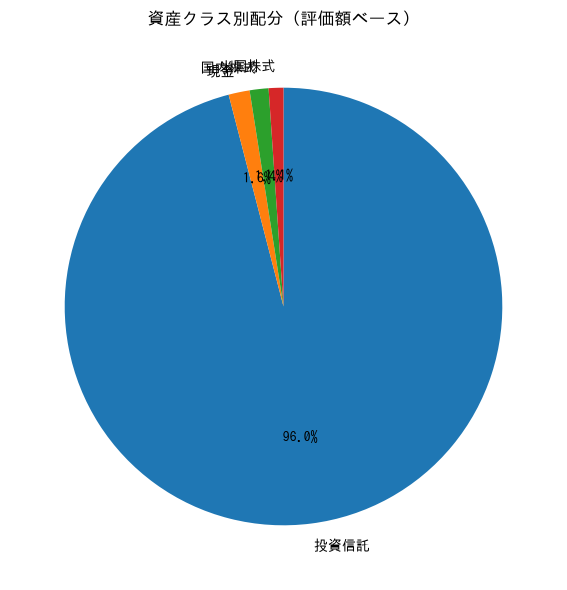

In [4]:
class_value = df.groupby("資産クラス")["評価額"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 6))
class_value.plot(
    kind="pie", ax=ax, autopct="%1.1f%%", startangle=90, counterclock=False,
    ylabel="",
)
ax.set_title("資産クラス別配分（評価額ベース）")
plt.tight_layout()
plt.show()


## 可視化2：銘柄別評価額


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


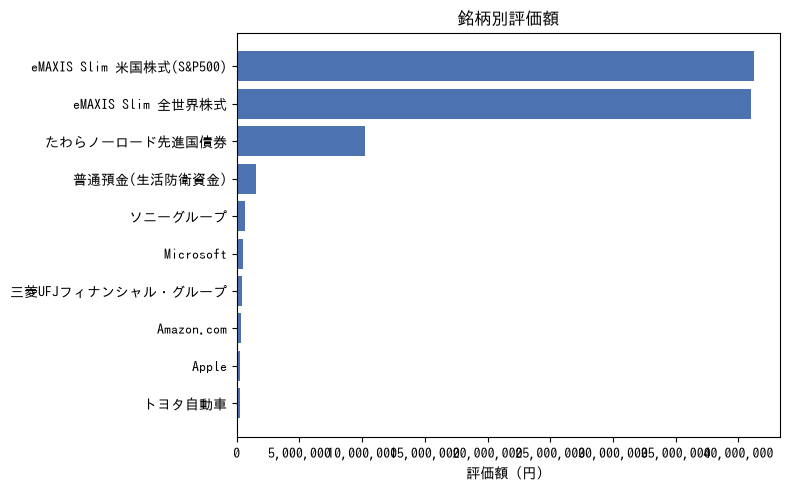

In [5]:
value_by_stock = df.set_index("銘柄名")["評価額"].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(value_by_stock.index, value_by_stock.values, color="#4C72B0")
ax.set_title("銘柄別評価額")
ax.set_xlabel("評価額（円）")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


## 可視化3：銘柄別評価損益
黒字は青，赤字は赤で色分けしています．


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


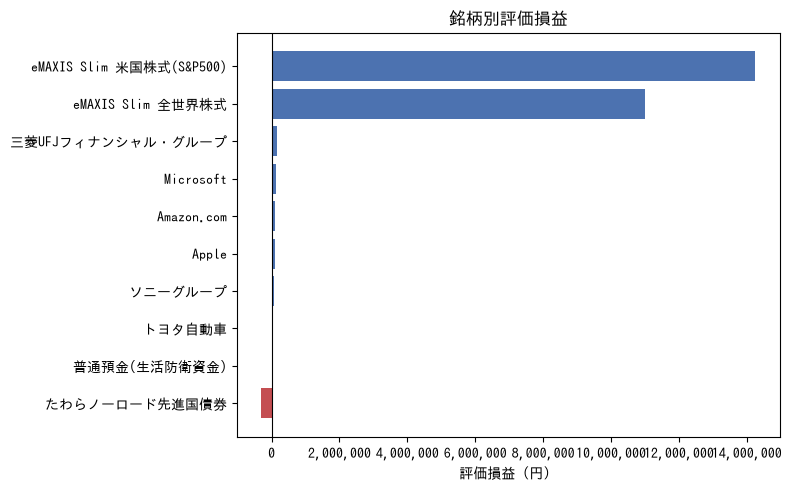

In [6]:
pl_by_stock = df.set_index("銘柄名")["評価損益"].sort_values()
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in pl_by_stock.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(pl_by_stock.index, pl_by_stock.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("銘柄別評価損益")
ax.set_xlabel("評価損益（円）")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
